#GRAPH NEURAL NETWORKS
---

##0.REFERENCE AND CONTEXT

**CHAPTER 10**
**Graph Neural Networks (GNNs) for Node Classification Using the Cora Citation Network**

**Introduction**

Graph Neural Networks represent one of the most important advances in modern machine learning. While Deep Neural Networks excel at tabular data, Convolutional Neural Networks excel at images, and Transformers excel at language, Graph Neural Networks are specifically designed for relational data. Many real-world systems naturally exist as networks: social networks, recommendation systems, financial transaction networks, biological systems, supply chains, citation networks, and knowledge graphs. Traditional machine learning approaches often struggle to exploit the rich relational structure contained within these systems. Graph Neural Networks solve this problem by explicitly modeling connections among entities.

The fundamental idea behind a Graph Neural Network is message passing. Each node in a graph receives information from its neighbors, aggregates that information, and updates its internal representation. By repeatedly applying this process, nodes learn increasingly rich contextual representations. A node is therefore characterized not only by its own features but also by the structure of its surrounding neighborhood. This concept is analogous to how humans interpret information in social contexts. Understanding a person often requires understanding their relationships, affiliations, and interactions with others.

In this notebook we use the Cora citation network, one of the most widely used benchmark datasets in graph machine learning. In the Cora dataset, each node represents an academic paper, and each edge represents a citation relationship between two papers. Each paper is represented by a vector describing the words that appear in the document, and the objective is to predict the research field of the paper. This makes Cora an ideal educational dataset because students can clearly understand both the nodes and the relationships.

The Graph Convolutional Network (GCN) architecture introduced in this chapter extends the concept of convolution from regular grids to irregular graph structures. Whereas a CNN aggregates information from nearby pixels, a GCN aggregates information from neighboring nodes. This simple but powerful idea allows graph-based learning systems to achieve remarkable performance across a wide range of applications.

Students will learn how graphs are represented mathematically, how message passing works, how graph convolutions are implemented, how node embeddings are generated, and how node classification is performed. Visualization of graph embeddings will demonstrate how GNNs organize relational information into meaningful geometric structures.

By the end of this notebook, students will understand the foundations of Graph Neural Networks and appreciate why they have become essential tools in recommendation systems, fraud detection, social network analysis, scientific discovery, and knowledge graph applications.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the environment. It installs PyTorch Geometric, imports required libraries, configures reproducibility, creates project folders, and verifies GPU availability.

In [1]:
# CELL 1
# Environment Setup

!pip -q install torch-geometric

import os
import json
import random
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path("/content/chapter10_gnn")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime("run_%Y%m%d_%H%M%S_utc")

print("Run ID:", RUN_ID)
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.9 MB/s eta 0:00:00
Run ID: run_20260606_123510_utc
PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU: NVIDIA A100-SXM4-80GB


##2.THE CORA CITATION NETWORK.THE DATASET

**Explanation for Cell 2**

This cell loads the Cora citation network. The dataset contains papers, citation relationships, node features, and research-field labels.

In [3]:
# CELL 2
# Load Dataset

from torch_geometric.datasets import Planetoid

dataset = Planetoid(
    root="/tmp/Cora",
    name="Cora"
)

data = dataset[0]

print(dataset)

print("\nNumber of graphs:", len(dataset))
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)
print("Number of features:", dataset.num_features)
print("Number of classes:", dataset.num_classes)

Processing...


Cora()

Number of graphs: 1
Number of nodes: 2708
Number of edges: 10556
Number of features: 1433
Number of classes: 7


Done!


##3.GRAPH STRUCTURE

**Explanation for Cell 3**

This cell explores the graph structure and displays summary statistics.

In [4]:
# CELL 3
# Graph Exploration

print(data)

print("\nTraining Nodes:",
      int(data.train_mask.sum()))

print("Validation Nodes:",
      int(data.val_mask.sum()))

print("Test Nodes:",
      int(data.test_mask.sum()))

degree = torch.bincount(
    data.edge_index[0]
)

print("\nAverage Degree:",
      float(degree.float().mean()))

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

Training Nodes: 140
Validation Nodes: 500
Test Nodes: 1000

Average Degree: 3.8980798721313477


##4.VISUALIZATION

**Explanation for Cell 4**

This cell visualizes a subset of the graph structure.

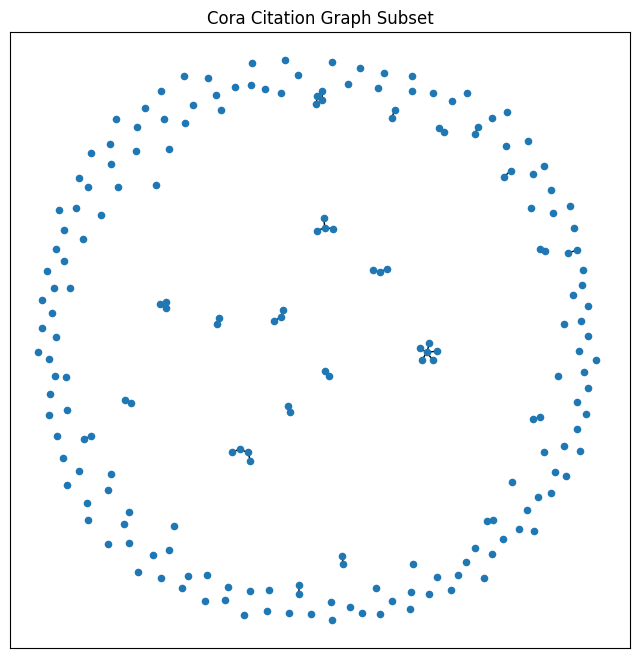

In [6]:
# CELL 4
# Graph Visualization

from torch_geometric.utils import to_networkx
import networkx as nx

graph = to_networkx(
    data,
    to_undirected=True
)

subset_nodes = list(graph.nodes())[:200]

subgraph = graph.subgraph(subset_nodes)

plt.figure(figsize=(8,8))

nx.draw_networkx(
    subgraph,
    node_size=20,
    with_labels=False
)

plt.title(
    "Cora Citation Graph Subset"
)

plt.show()
plt.close()

##5.GRAPH CONVOLUTIONAL NEURAL NETWORK

**Explanation for Cell 5**

This cell defines the Graph Convolutional Network architecture. Two graph convolution layers are used for message passing and node classification.

In [7]:
# CELL 5
# Build GCN

import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(
            dataset.num_features,
            16
        )

        self.conv2 = GCNConv(
            16,
            dataset.num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        return x

model = GCN()

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)
data = data.to(device)

print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


##6.TRAINING

**Explanation for Cell 6**

This cell trains the Graph Neural Network.

In [8]:
# CELL 6
# Training

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

loss_history = []

model.train()

for epoch in range(100):

    optimizer.zero_grad()

    output = model(data)

    loss = F.cross_entropy(
        output[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    loss_history.append(
        float(loss.item())
    )

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} "
            f"Loss {loss.item():.4f}"
        )

Epoch 000 Loss 1.9410
Epoch 010 Loss 0.7651
Epoch 020 Loss 0.2538
Epoch 030 Loss 0.1243
Epoch 040 Loss 0.0851
Epoch 050 Loss 0.0673
Epoch 060 Loss 0.0345
Epoch 070 Loss 0.0473
Epoch 080 Loss 0.0403
Epoch 090 Loss 0.0257


##7.EVALUATION OF NODE CLASSIFICATION PERFORMANCE

**Explanation for Cell 7**

This cell evaluates node classification performance.

In [9]:
# CELL 7
# Evaluation

model.eval()

predictions = model(data).argmax(
    dim=1
)

correct = (
    predictions[data.test_mask]
    ==
    data.y[data.test_mask]
)

accuracy = int(correct.sum()) / int(
    data.test_mask.sum()
)

print(
    f"Test Accuracy: {accuracy:.4f}"
)

evaluation_results = {
    "test_accuracy": float(accuracy)
}

print(evaluation_results)

Test Accuracy: 0.7880
{'test_accuracy': 0.788}


##8.VISUALIZATION

**Explanation for Cell 8**

This cell visualizes the node embeddings learned by the GNN.

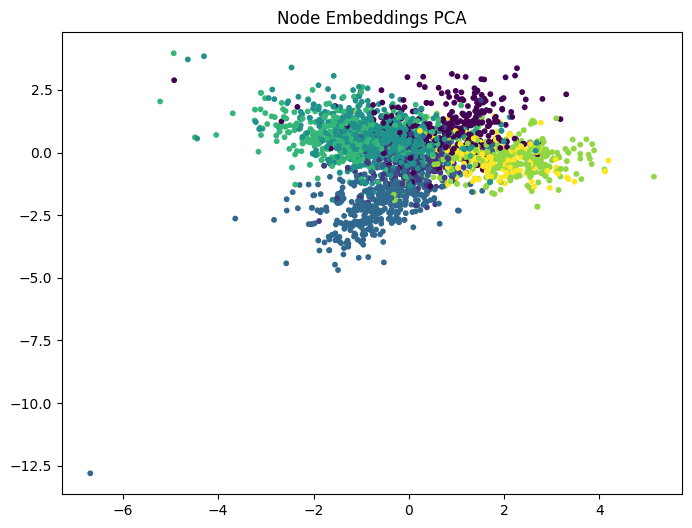

In [10]:
# CELL 8
# Embedding Visualization

from sklearn.decomposition import PCA

model.eval()

with torch.no_grad():

    embeddings = model.conv1(
        data.x,
        data.edge_index
    )

embeddings = (
    embeddings.cpu()
    .numpy()
)

labels = (
    data.y.cpu()
    .numpy()
)

pca = PCA(
    n_components=2,
    random_state=SEED
)

embeddings_2d = pca.fit_transform(
    embeddings
)

plt.figure(figsize=(8,6))

plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=labels,
    s=10
)

plt.title(
    "Node Embeddings PCA"
)

plt.show()
plt.close()

##9.PREDICTIONS AND CLASS DISTRIBUTIONS

**Explanation for Cell 9**

This cell analyzes predictions and class distributions.

In [11]:
# CELL 9
# Prediction Analysis

predictions_cpu = (
    predictions.cpu()
    .numpy()
)

labels_cpu = (
    data.y.cpu()
    .numpy()
)

for i in range(10):

    print(
        "Node:",
        i,
        "True:",
        labels_cpu[i],
        "Predicted:",
        predictions_cpu[i]
    )

Node: 0 True: 3 Predicted: 3
Node: 1 True: 4 Predicted: 4
Node: 2 True: 4 Predicted: 4
Node: 3 True: 0 Predicted: 0
Node: 4 True: 3 Predicted: 3
Node: 5 True: 2 Predicted: 2
Node: 6 True: 0 Predicted: 0
Node: 7 True: 3 Predicted: 3
Node: 8 True: 3 Predicted: 3
Node: 9 True: 2 Predicted: 2


##10.VISUALIZATION OF TRAINING DYNAMICS

**Explanation for Cell 10**

This cell visualizes training dynamics and model explainability.

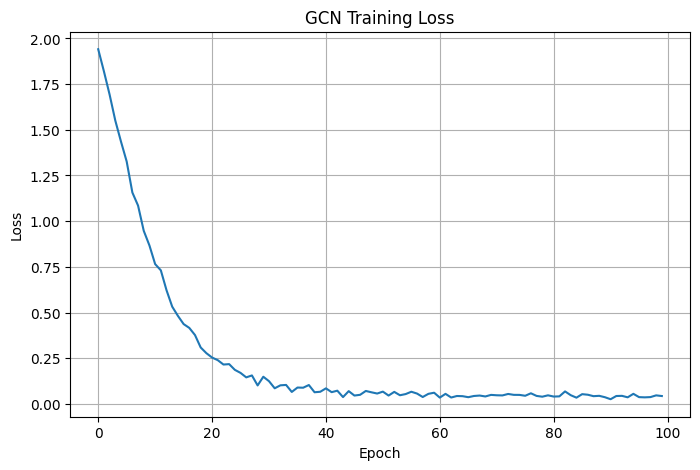

Final Training Loss: 0.04311899095773697


In [12]:
# CELL 10
# Training Dynamics

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title(
    "GCN Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()
plt.close()

print(
    "Final Training Loss:",
    loss_history[-1]
)

##11.EXPLANATION AND SUMMARIZATION

**Explanation for Cell 11**

This cell uses GPT-5.2 to explain the results of the Graph Neural Network experiment.

In [13]:
# CELL 11
# GPT-5.2 Analysis

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

summary = {
    "dataset": "Cora",
    "nodes": int(data.num_nodes),
    "edges": int(data.num_edges),
    "features": int(dataset.num_features),
    "classes": int(dataset.num_classes),
    "accuracy": float(accuracy)
}

response = client.responses.create(
    model="gpt-5.2",
    input=f"""
Analyze this Graph Neural Network
experiment.

Return strict JSON.

{json.dumps(summary, indent=2)}
"""
)

print(response.output_text)

{
  "dataset_summary": {
    "name": "Cora",
    "num_nodes": 2708,
    "num_edges": 10556,
    "num_features": 1433,
    "num_classes": 7
  },
  "reported_performance": {
    "metric": "accuracy",
    "value": 0.788
  },
  "derived_graph_stats": {
    "is_undirected_assumption": "unknown",
    "average_degree_if_undirected": 7.798,
    "average_out_degree_if_directed": 3.898,
    "edge_to_node_ratio": 3.898,
    "feature_dimensionality": "high"
  },
  "contextual_interpretation": {
    "typical_baseline_range_on_cora": {
      "note": "Varies by split, model, and preprocessing; this is a rough reference band for common citation-network splits.",
      "approx_accuracy_range": [
        0.78,
        0.83
      ]
    },
    "assessment": "The reported accuracy (0.788) is within a common baseline range for Cora, suggesting a reasonable but not state-of-the-art result under many standard setups."
  },
  "checks_and_questions_for_reproducibility": {
    "missing_critical_details": [
     

##12.CONCLUSION

**Conclusion**

This notebook introduced Graph Neural Networks through the Cora citation network benchmark. Unlike previous models that processed independent observations, Graph Neural Networks explicitly leveraged relationships among entities. This relational perspective represents one of the most important developments in modern machine learning because many real-world systems naturally exist as interconnected networks.

Students learned the core concept of message passing, where nodes exchange information with their neighbors and update their internal representations. This process allows each node to incorporate local graph structure into its learned embedding. Through repeated graph convolution operations, nodes gradually acquire richer contextual information that improves predictive performance.

The Graph Convolutional Network demonstrated how relational information can dramatically enhance learning. Rather than classifying papers solely from their textual features, the model also considered citation relationships. Papers frequently cite other papers within the same research field, and the GNN successfully exploited this structure. The resulting node embeddings captured both content and connectivity information.

The embedding visualization illustrated one of the most powerful ideas in representation learning. Papers belonging to similar research areas tended to cluster together in embedding space. This demonstrates how Graph Neural Networks transform complex relational systems into structured geometric representations that support prediction and analysis.

Graph Neural Networks have become foundational technologies across numerous industries. Recommendation systems leverage graph structures connecting users and products. Fraud detection systems model financial transactions as networks. Social media platforms analyze user interactions through graphs. Biological researchers study molecular and protein interaction networks. Knowledge graphs power search engines and question-answering systems. In all these applications, relational structure is as important as individual features.

This chapter also highlighted the importance of PyTorch Geometric, which has emerged as the standard framework for graph machine learning research. Students learned how modern graph datasets are loaded, how graph convolution layers are implemented, and how node classification tasks are performed using contemporary tooling.

Most importantly, this notebook expanded the student's understanding of machine learning beyond traditional data structures. The progression from tabular data, to images, to sequences, to language, and finally to graphs reflects the increasing complexity of real-world information systems. Graph Neural Networks provide the tools necessary to model these complex interconnected environments.

The next chapter will move beyond predictive modeling into decision-making systems through Reinforcement Learning. While Graph Neural Networks learn from relational data, Reinforcement Learning introduces agents that learn through interaction with their environment. Together, these chapters form the foundation for many advanced AI systems used in robotics, autonomous systems, recommendation engines, and intelligent agents.